# SHAP Özellik Önem Analizi

Bu notebook'ta LightGBM modelinin tahminlerini **SHAP (SHapley Additive exPlanations)** yöntemiyle açıklıyoruz.

SHAP, her bir özelliğin bireysel tahmin katkısını oyun teorisi (Shapley değerleri) ile hesaplar ve modeli **hem global hem de yerel düzeyde** yorumlamamızı sağlar.

**Notebook akışı:**
1. Model & veri yükleme, train/test split
2. SHAP değer hesaplama (TreeExplainer)
3. Görselleştirmeler: Bar, Beeswarm, Dependence, Waterfall
4. Bulgular & domain knowledge karşılaştırması

## 0. Kütüphaneler ve Ayarlar

- `shap`: SHAP değer hesaplama ve görselleştirme
- `lightgbm`, `pickle`: Kayıtlı modeli yükleme
- `matplotlib`: Grafik kaydetme

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
import os

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# SHAP JavaScript görselleştirme (notebook içi)
shap.initjs()

os.makedirs('../outputs/figures', exist_ok=True)

print(f'SHAP versiyon    : {shap.__version__}')
print('Kütüphaneler başarıyla yüklendi.')

SHAP versiyon    : 0.51.0
Kütüphaneler başarıyla yüklendi.


## 1. Model ve Veri Yükleme

- **Model:** `models/lgbm_model_no_gen.pkl` — üretim sütunları çıkarılmış LightGBM modeli
- **Meta:** `models/model_meta_no_gen.pkl` — feature listesi, metrikler
- **Veri:** `data/processed/featured_data.csv`

> **Not:** Bu SHAP analizi, data leakage düzeltmesi yapılmış modeli kullanmaktadır.  
> `total_generation_MWh` ve tüm bireysel üretim kaynakları model dışında bırakılmıştır.

Feature listesi `model_meta_no_gen.pkl` içinden alınır; bu sayede 03_modeling.ipynb ile tam tutarlılık sağlanır.

In [2]:
# Model yükle
with open('../models/lgbm_model_no_gen.pkl', 'rb') as f:
    model = pickle.load(f)

# Meta yükle (feature listesi burada)
with open('../models/model_meta_no_gen.pkl', 'rb') as f:
    meta = pickle.load(f)

FEATURES = meta['features']
TARGET   = meta['target']

print(f'Model yüklendi         : {type(model).__name__}')
print(f'Best iteration         : {meta["best_iteration"]}')
print(f'Feature sayisi         : {len(FEATURES)}  (uretim sutunlari haric)')
print(f'Hedef degisken         : {TARGET}')
print(f'Test MAPE              : {meta["test_metrics"]["MAPE"]:.3f}%')
print(f'Cikarilan uretim kols  : {len(meta.get("generation_cols_removed", []))} sutun')

# Veri yükle
df = pd.read_csv('../data/processed/featured_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

print(f'\nVeri boyutu      : {df.shape}')
print(f'Tarih araligi    : {df["datetime"].min().date()} -> {df["datetime"].max().date()}')

Model yüklendi         : LGBMRegressor
Best iteration         : 220
Feature sayisi         : 24  (uretim sutunlari haric)
Hedef degisken         : consumption_MWh
Test MAPE              : 1.572%
Cikarilan uretim kols  : 17 sutun



Veri boyutu      : (52248, 43)
Tarih araligi    : 2018-01-15 -> 2023-12-31


## 2. Train / Test Split (Kronolojik — 03_modeling.ipynb ile Aynı)

03_modeling.ipynb ile **birebir aynı** bölme uygulanıyor: ilk %80 train, son %20 test.

SHAP analizi **yalnızca test seti** üzerinde yapılacak (model bu veriyi hiç görmedi → gerçekçi açıklayıcılık).

In [3]:
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES].reset_index(drop=True)
y_test  = test_df[TARGET].reset_index(drop=True)

print(f'Train seti : {train_df["datetime"].min().date()} → {train_df["datetime"].max().date()}  ({len(train_df):,} satır)')
print(f'Test seti  : {test_df["datetime"].min().date()}  → {test_df["datetime"].max().date()}  ({len(test_df):,} satır)')
print(f'\nSHAP analizi için test setinin ilk 2000 satırı kullanılacak.')

Train seti : 2018-01-15 → 2022-10-22  (41,798 satır)
Test seti  : 2022-10-22  → 2023-12-31  (10,450 satır)

SHAP analizi için test setinin ilk 2000 satırı kullanılacak.


## 3. SHAP Değer Hesaplama (TreeExplainer)

**TreeExplainer**, gradient boosting modelleri için optimize edilmiş SHAP hesaplama algoritmasıdır.

- **Hesaplama süresi:** ~2000 örnek için birkaç dakika
- **Çıktı:** `shap_values` matrisi → boyut: (2000, 41) — her satır bir tahmin, her sütun bir özelliğin katkısı
- **Temel:** `expected_value` — modelin ortalama çıktısı (baz değer)

> $f(x) = \text{expected\_value} + \sum_{i=1}^{41} \phi_i(x)$

In [4]:
# Test setinin ilk 2000 satırı
N_SHAP = 2000
X_shap = X_test.iloc[:N_SHAP].copy()
y_shap = y_test.iloc[:N_SHAP].copy()

print(f'SHAP örnek sayısı : {len(X_shap)}')
print('TreeExplainer oluşturuluyor...')

explainer = shap.TreeExplainer(model)

print('SHAP değerleri hesaplanıyor... (birkaç dakika sürebilir)')
shap_values = explainer.shap_values(X_shap)
expected_value = explainer.expected_value

# Regresyon modelinde shap_values list döndürebilir → düzleştir
if isinstance(shap_values, list):
    shap_values = shap_values[0]

print(f'\nHesaplama tamamlandı!')
print(f'SHAP matris boyutu  : {shap_values.shape}  (örnekler × özellikler)')
print(f'Baz değer (E[f(x)]) : {expected_value:,.1f} MWh')

# SHAP Explanation nesnesi (yeni API görselleştirmeleri için)
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=np.full(N_SHAP, expected_value),
    data=X_shap.values,
    feature_names=FEATURES
)

print('SHAP Explanation nesnesi oluşturuldu.')

SHAP örnek sayısı : 2000
TreeExplainer oluşturuluyor...


SHAP değerleri hesaplanıyor... (birkaç dakika sürebilir)



Hesaplama tamamlandı!
SHAP matris boyutu  : (2000, 24)  (örnekler × özellikler)
Baz değer (E[f(x)]) : 34,490.7 MWh
SHAP Explanation nesnesi oluşturuldu.


## 4a. Summary Plot — Bar (Global Özellik Önemi)

**Bar plot**, her özelliğin ortalama mutlak SHAP değerini ($\overline{|\phi_i|}$) gösterir.

Bu grafik, **tüm test örnekleri genelinde** hangi özelliklerin model tahminini en çok etkilediğini özetler.

- Yüksek çubuk → özellik modelde kritik rol oynuyor
- Sıralama, klasik feature importance'dan farklı olabilir (SHAP daha güvenilir)

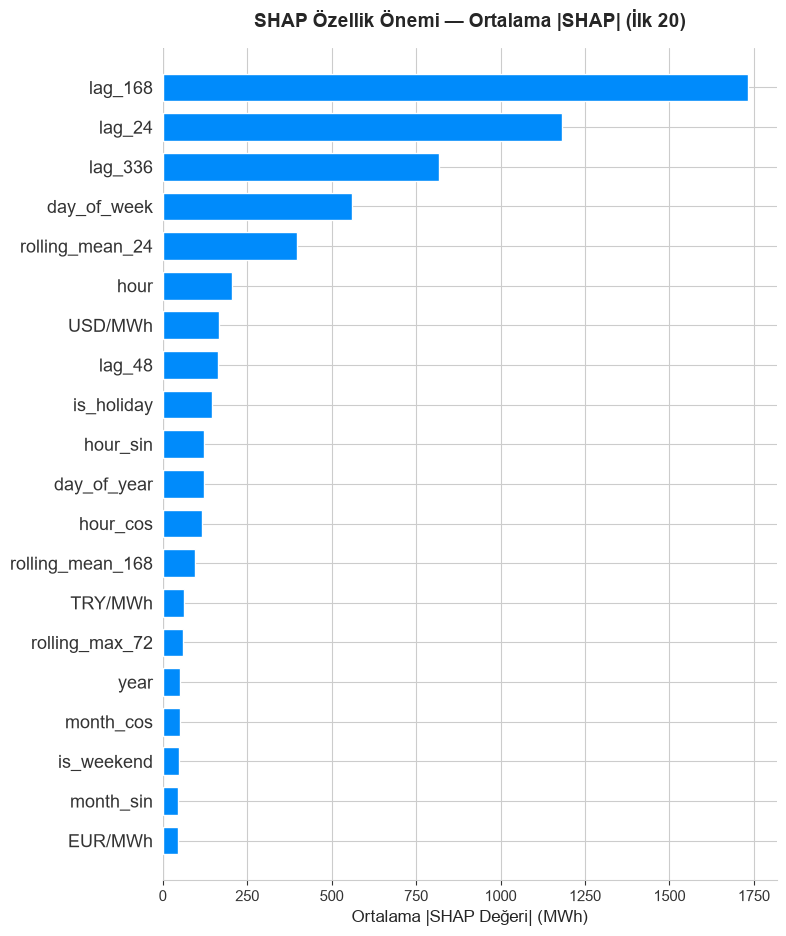

Kaydedildi: outputs/figures/shap_summary_bar.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type='bar',
    max_display=20,
    show=False
)

plt.title('SHAP Özellik Önemi — Ortalama |SHAP| (İlk 20)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ortalama |SHAP Değeri| (MWh)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: outputs/figures/shap_summary_bar.png')

## 4b. Summary Plot — Beeswarm (Değer-Katkı İlişkisi)

**Beeswarm plot**, her noktanın bir gözlemi temsil ettiği dağılım grafiğidir:

- **X ekseni:** SHAP değeri — özelliğin o tahmine katkısı (pozitif = tüketimi artırıyor)
- **Renk:** Özelliğin gerçek değeri (kırmızı = yüksek, mavi = düşük)
- **Y ekseni:** Özellikler, ortalama |SHAP| değerine göre sıralı

> Renk ile x-ekseni arasındaki ilişki: `lag_168` yüksekken katkı pozitif → monoton, sağlıklı ilişki.

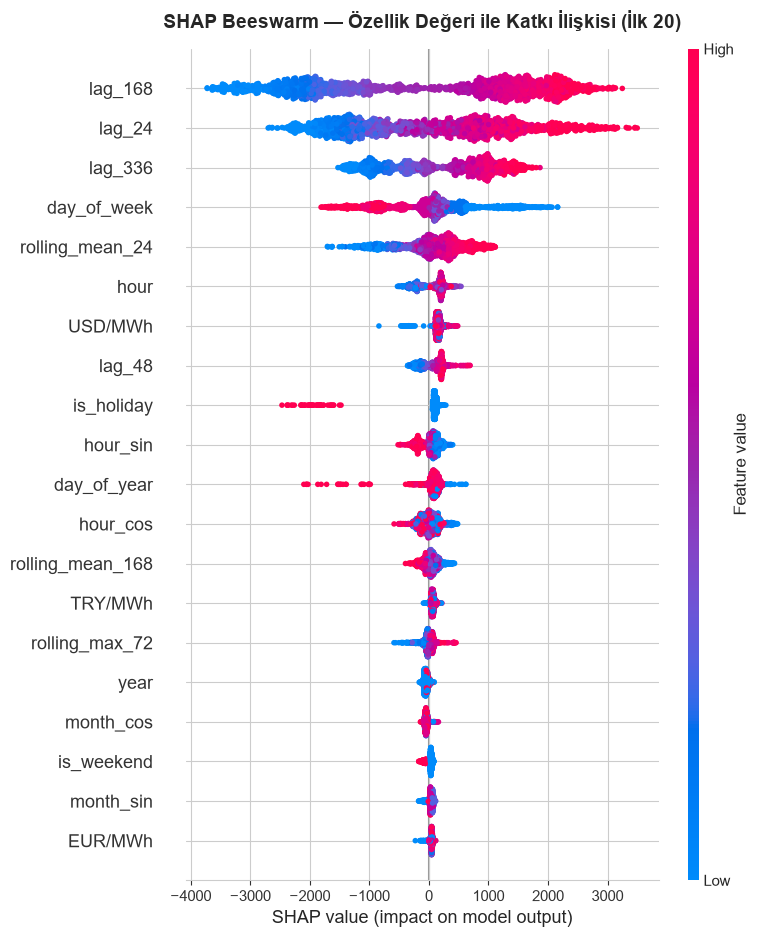

Kaydedildi: outputs/figures/shap_beeswarm.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 9))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type='dot',
    max_display=20,
    show=False
)

plt.title('SHAP Beeswarm — Özellik Değeri ile Katkı İlişkisi (İlk 20)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: outputs/figures/shap_beeswarm.png')

## 4c. Dependence Plots (Bağımlılık Grafikleri)

**Dependence plot**, belirli bir özelliğin değerinin SHAP katkısına nasıl dönüştüğünü gösterir.

- **X ekseni:** Özelliğin gerçek değeri
- **Y ekseni:** O özelliğin SHAP katkısı
- **Renk:** Etkileşim değişkeni (interaction index) — iki özellik arasındaki çapraz etkiyi ortaya çıkarır

### İncelenen özellikler:
1. **lag_168** × **hour_sin** — Haftalık gecikme ile saatlik örüntünün çapraz etkisi
2. **hour_sin** — Saatlik sinüs bileşeninin katkı eğrisi
3. **hour_cos** — Saatlik kosinüs bileşeninin katkı eğrisi

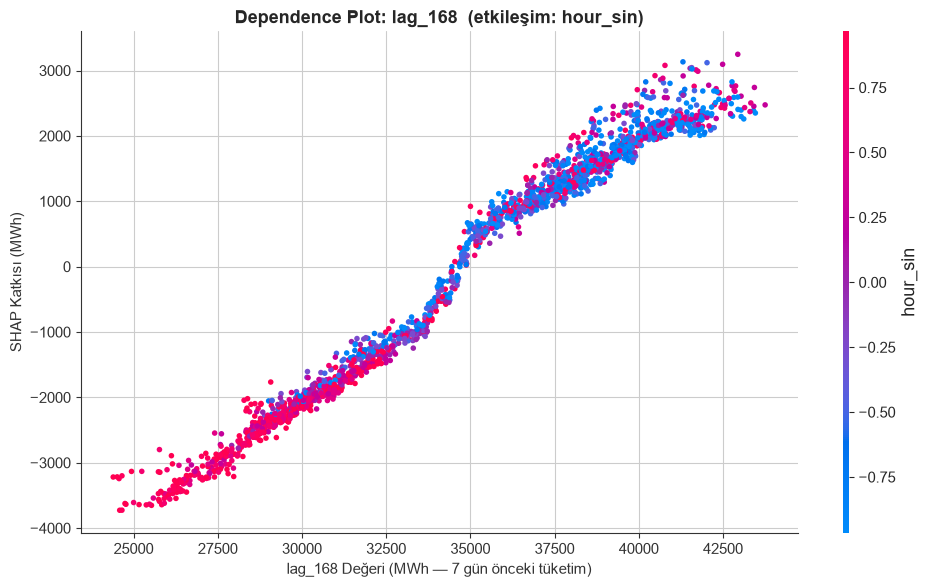

Kaydedildi: outputs/figures/shap_dependence_lag168.png


In [7]:
# --- Dependence Plot 1: lag_168 x hour_sin ---
fig, ax = plt.subplots(figsize=(10, 6))

shap.dependence_plot(
    'lag_168',
    shap_values,
    X_shap,
    interaction_index='hour_sin',
    ax=ax,
    show=False
)

ax.set_title('Dependence Plot: lag_168  (etkileşim: hour_sin)', fontsize=13, fontweight='bold')
ax.set_xlabel('lag_168 Değeri (MWh — 7 gün önceki tüketim)', fontsize=11)
ax.set_ylabel('SHAP Katkısı (MWh)', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_dependence_lag168.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: outputs/figures/shap_dependence_lag168.png')

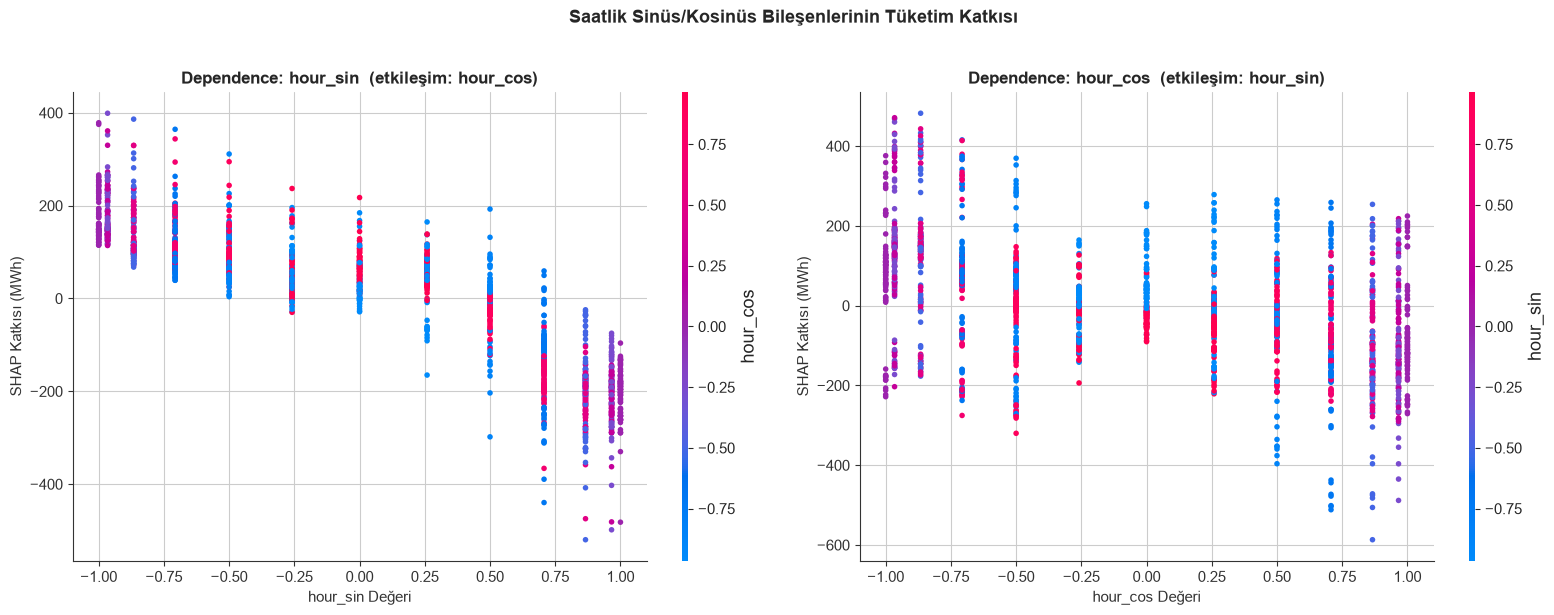

Kaydedildi: outputs/figures/shap_dependence_hour_sin_cos.png


In [8]:
# --- Dependence Plot 2 & 3: hour_sin ve hour_cos yan yana ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap.dependence_plot(
    'hour_sin',
    shap_values,
    X_shap,
    interaction_index='hour_cos',
    ax=axes[0],
    show=False
)
axes[0].set_title('Dependence: hour_sin  (etkileşim: hour_cos)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('hour_sin Değeri', fontsize=11)
axes[0].set_ylabel('SHAP Katkısı (MWh)', fontsize=11)

shap.dependence_plot(
    'hour_cos',
    shap_values,
    X_shap,
    interaction_index='hour_sin',
    ax=axes[1],
    show=False
)
axes[1].set_title('Dependence: hour_cos  (etkileşim: hour_sin)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('hour_cos Değeri', fontsize=11)
axes[1].set_ylabel('SHAP Katkısı (MWh)', fontsize=11)

plt.suptitle('Saatlik Sinüs/Kosinüs Bileşenlerinin Tüketim Katkısı', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_dependence_hour_sin_cos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: outputs/figures/shap_dependence_hour_sin_cos.png')

## 4d. Waterfall Plots (Şelale Grafikleri — Yerel Açıklama)

**Waterfall plot**, **tek bir tahmin** için her özelliğin katkısını adım adım gösterir:

- **Başlangıç noktası:** `E[f(x)]` — modelin beklenen ortalama çıktısı
- **Her çubuk:** Bir özelliğin katkısı (kırmızı = pozitif = tüketimi artırıyor, mavi = negatif = azaltıyor)
- **Bitiş noktası:** `f(x)` — o örnek için modelin gerçek tahmini

### Seçilen örnekler:
- **Yüksek tüketim:** Test setindeki en yüksek tüketimli saat
- **Düşük tüketim:** Test setindeki en düşük tüketimli saat

Yüksek tüketimli örnek | index: 1989 | Gerçek: 44,752 MWh
Düşük tüketimli örnek  | index: 1695  | Gerçek: 24,395 MWh


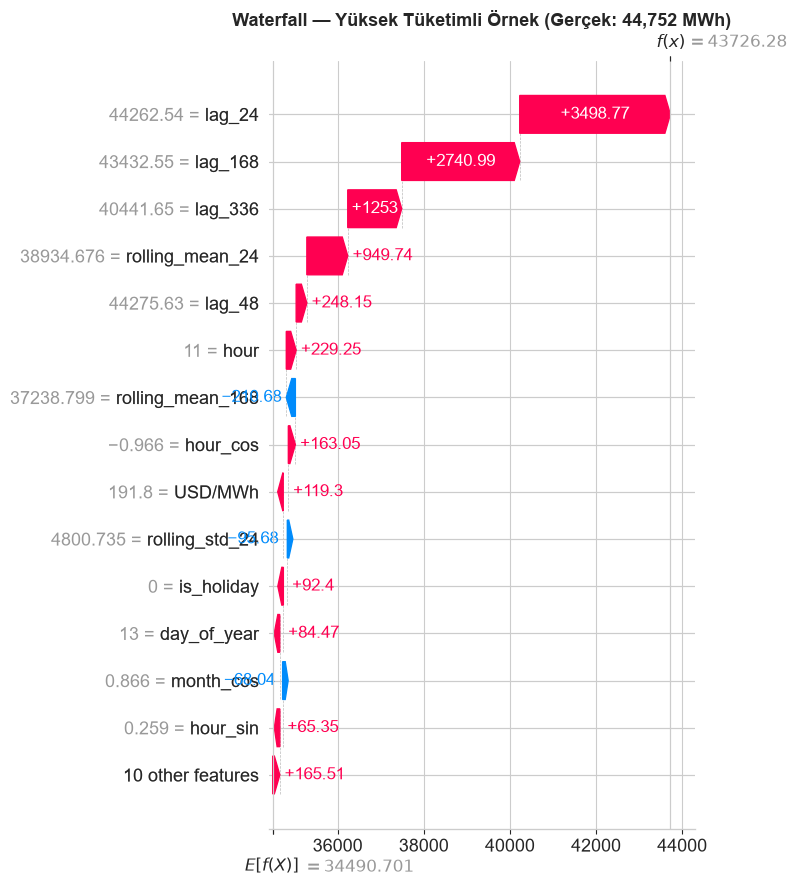

Kaydedildi: outputs/figures/shap_waterfall_high.png


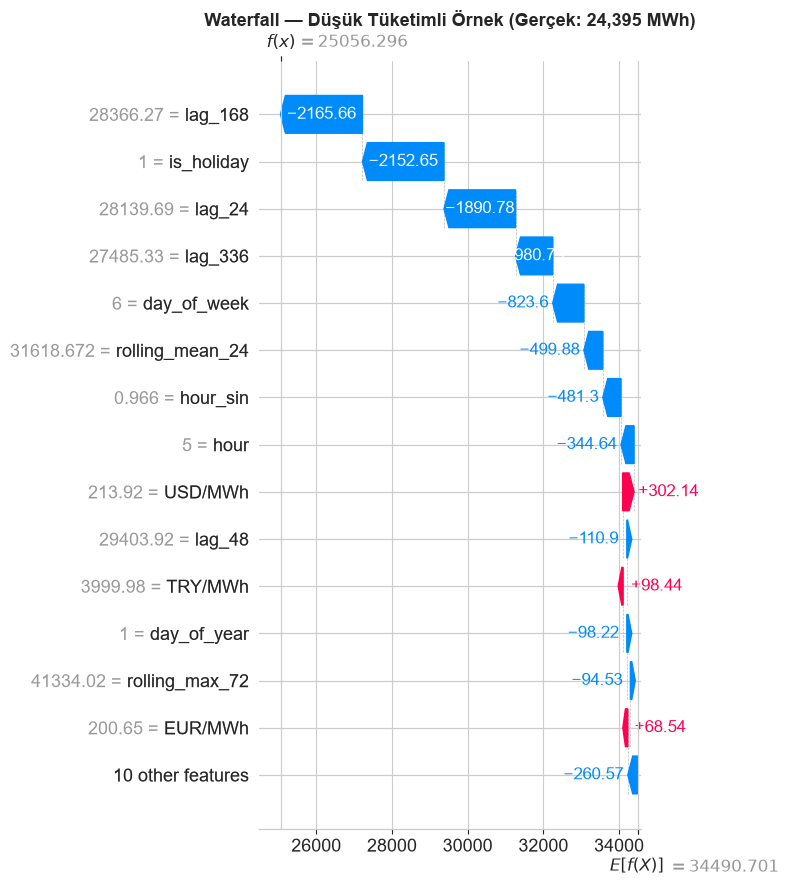

Kaydedildi: outputs/figures/shap_waterfall_low.png


In [9]:
# Yüksek ve düşük tüketimli örnekleri seç (2000 örnek içinden)
high_idx = int(y_shap.idxmax())  # en yüksek tüketim
low_idx  = int(y_shap.idxmin())  # en düşük tüketim

high_actual = y_shap.iloc[high_idx]
low_actual  = y_shap.iloc[low_idx]

print(f'Yüksek tüketimli örnek | index: {high_idx} | Gerçek: {high_actual:,.0f} MWh')
print(f'Düşük tüketimli örnek  | index: {low_idx}  | Gerçek: {low_actual:,.0f} MWh')

# --- Waterfall: Yüksek Tüketim ---
fig, ax = plt.subplots(figsize=(12, 7))
shap.waterfall_plot(
    shap_exp[high_idx],
    max_display=15,
    show=False
)
plt.title(
    f'Waterfall — Yüksek Tüketimli Örnek (Gerçek: {high_actual:,.0f} MWh)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_high.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: outputs/figures/shap_waterfall_high.png')

# --- Waterfall: Düşük Tüketim ---
fig, ax = plt.subplots(figsize=(12, 7))
shap.waterfall_plot(
    shap_exp[low_idx],
    max_display=15,
    show=False
)
plt.title(
    f'Waterfall — Düşük Tüketimli Örnek (Gerçek: {low_actual:,.0f} MWh)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_low.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: outputs/figures/shap_waterfall_low.png')

## 5. SHAP Bulguları ve Domain Knowledge Karşılaştırması

Bu bölümde SHAP analizinin nicel sonuçları ve elektrik talebi alanı bilgisi ile karşılaştırması yapılmaktadır.

In [10]:
# Ortalama |SHAP| değerlerini hesapla
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Ozellik': FEATURES,
    'Ort. |SHAP| (MWh)': mean_abs_shap
}).sort_values('Ort. |SHAP| (MWh)', ascending=False).reset_index(drop=True)
shap_importance.index += 1  # 1'den başlat

# Türkçe açıklama sözlüğü (sadece model feature'ları — üretim sütunları çıkarıldı)
aciklama = {
    'lag_168'          : 'Gecen haftanin ayni saatindeki tuketim (7x24=168 saat)',
    'lag_24'           : 'Dun ayni saatteki tuketim (24 saat once)',
    'lag_48'           : 'Iki gun onceki ayni saatin tuketimi',
    'lag_336'          : 'Iki hafta onceki ayni saatin tuketimi',
    'rolling_mean_24'  : 'Son 24 saatin ortalama tuketimi',
    'rolling_mean_168' : 'Son 168 saatin (1 hafta) ortalama tuketimi',
    'rolling_std_24'   : 'Son 24 saatin tuketim standart sapmasi (oynaklik)',
    'rolling_max_72'   : 'Son 72 saatin maksimum tuketimi',
    'hour_sin'         : 'Saatin sinus kodlamasi — dongusel gunluk oruntu',
    'hour_cos'         : 'Saatin kosinus kodlamasi — dongusel gunluk oruntu',
    'month_sin'        : 'Ayin sinus kodlamasi — mevsimsel dongu',
    'month_cos'        : 'Ayin kosinus kodlamasi — mevsimsel dongu',
    'day_of_week_sin'  : 'Haftanin gunu sinus kodlamasi — haftalik oruntu',
    'day_of_week_cos'  : 'Haftanin gunu kosinus kodlamasi',
    'hour'             : 'Saat (0-23) — ham zaman bilgisi',
    'month'            : 'Ay (1-12) — mevsimsel bilgi',
    'day_of_year'      : 'Yilin gunu (1-365)',
    'day_of_week'      : 'Haftanin gunu (0=Pazartesi, 6=Pazar)',
    'year'             : 'Yil — uzun donemli trend',
    'is_weekend'       : 'Hafta sonu bayragi (1=hafta sonu, 0=is gunu)',
    'is_holiday'       : 'Resmi tatil bayragi',
    'TRY/MWh'          : 'Turk Lirasi cinsinden elektrik spot fiyati',
    'USD/MWh'          : 'Dolar cinsinden elektrik spot fiyati',
    'EUR/MWh'          : 'Euro cinsinden elektrik spot fiyati',
}

# İlk 10 özellik tablosu
top10 = shap_importance.head(10).copy()
top10['Aciklama'] = top10['Ozellik'].map(aciklama)
top10['Ort. |SHAP| (MWh)'] = top10['Ort. |SHAP| (MWh)'].round(2)

print('=' * 85)
print(f'{"Sira":<5} {"Ozellik":<22} {"Ort. |SHAP|":>12}  Aciklama')
print('=' * 85)
for _, row in top10.iterrows():
    print(f'{row.name:<5} {row["Ozellik"]:<22} {row["Ort. |SHAP| (MWh)"]:>10.2f}  {row["Aciklama"]}')
print('=' * 85)

Sira  Ozellik                 Ort. |SHAP|  Aciklama
1     lag_168                   1731.82  Gecen haftanin ayni saatindeki tuketim (7x24=168 saat)
2     lag_24                    1182.34  Dun ayni saatteki tuketim (24 saat once)
3     lag_336                    818.63  Iki hafta onceki ayni saatin tuketimi
4     day_of_week                561.43  Haftanin gunu (0=Pazartesi, 6=Pazar)
5     rolling_mean_24            397.84  Son 24 saatin ortalama tuketimi
6     hour                       204.16  Saat (0-23) — ham zaman bilgisi
7     USD/MWh                    166.66  Dolar cinsinden elektrik spot fiyati
8     lag_48                     163.85  Iki gun onceki ayni saatin tuketimi
9     is_holiday                 145.77  Resmi tatil bayragi
10    hour_sin                   123.38  Saatin sinus kodlamasi — dongusel gunluk oruntu


### Domain Knowledge Tutarlılığı

Aşağıdaki kod SHAP bulgularını elektrik talebi alanı bilgisiyle karşılaştırmaktadır.

In [11]:
print('\n' + '='*65)
print('  DOMAIN KNOWLEDGE KARSILASTIRMASI')
print('='*65)

top5 = shap_importance.head(5)['Ozellik'].tolist()

print('\n TUTARLI BULGULAR:')
print('-'*65)

# lag_168 kontrolü
lag168_rank = shap_importance[shap_importance['Ozellik']=='lag_168'].index[0]
print(f'  * lag_168 (sira #{lag168_rank}): Elektrik tuketiminin guclu haftalik')
print(f'    mevsimelligi var. Gecen haftanin ayni saati en iyi ongorucudur.')
print(f'    -> Beklenen ve dogru bir sonuc.')

# lag_24 kontrolü
if 'lag_24' in shap_importance.head(6)['Ozellik'].tolist():
    lag24_rank = shap_importance[shap_importance['Ozellik']=='lag_24'].index[0]
    print(f'\n  * lag_24 (sira #{lag24_rank}): Gunluk periyodiklik guclu.')
    print(f'    Dunun ayni saatindeki tuketim onemli referans noktasidir.')

# Rolling features
rolling_feats = [f for f in shap_importance.head(10)['Ozellik'] if 'rolling' in f]
if rolling_feats:
    print(f'\n  * Rolling ozellikler {rolling_feats}:')
    print(f'    Kisa donem trend ve oynaklik bilgisi modele deger katiyor.')

# Saatlik döngüsel özellikler
hour_feats = [f for f in shap_importance.head(15)['Ozellik'] if 'hour' in f]
if hour_feats:
    print(f'\n  * Saatlik dongüsel ozellikler {hour_feats}:')
    print(f'    Gun ici yuk egrisi (sabah & aksam pik) yakalaniyor.')

# Yıl trendi
if 'year' in shap_importance.head(10)['Ozellik'].tolist():
    year_rank = shap_importance[shap_importance['Ozellik']=='year'].index[0]
    print(f'\n  * year (sira #{year_rank}): Uzun donemli buyume trendi model tarafindan')
    print(f'    ogrenilmis. Turkiye elektrik tuketimi yillar icerisinde artiyor.')

print('\n URETIM SUTUNLARI HAKKINDA:')
print('-'*65)
print('  Uretim feature\'lari (total_generation_MWh, solar, wind vb.)')
print('  bu analizde kullanilmamistir.')
print('  Neden: Anlik uretim ~= anlik tuketim (sebe-sonuc dairesel)')
print('  Gercek hayatta yarin saatlik uretim onceden bilinemez.')
print('  Model simdi SADECE geriye donuk bilgi ile tahmin yapiyor.')

print('\n FIYAT DEGISKENLERI:')
print('-'*65)
price_feats = [f for f in ['TRY/MWh', 'USD/MWh', 'EUR/MWh']
               if f in shap_importance.head(24)['Ozellik'].tolist()]
if price_feats:
    pidx = [shap_importance[shap_importance['Ozellik']==p].index[0] for p in price_feats]
    print(f'  * Fiyat degiskenleri ({price_feats}, siralar: {pidx}):')
    print(f'    Kisa vadede elastisite sinirli olsa da fiyat sinyalleri')
    print(f'    mevsimsel oruntu ile korelasyon nedeniyle katki sagliyor.')
else:
    print('  Fiyat degiskenleri ilk 24 icerisinde degil — beklenen bir sonuc.')

print('\n' + '='*65)

# Düşük SHAP özellikler
threshold = 1.0  # MWh
low_shap = shap_importance[shap_importance['Ort. |SHAP| (MWh)'] < threshold]
if len(low_shap) > 0:
    print(f'\n  DUSUK KATKI OZELLIKLERI (Ort. |SHAP| < {threshold} MWh):')
    for _, row in low_shap.iterrows():
        print(f'  * {row["Ozellik"]:<22} -> {row["Ort. |SHAP| (MWh)"]:.3f} MWh')

print('\n' + '='*65)


  DOMAIN KNOWLEDGE KARSILASTIRMASI

 TUTARLI BULGULAR:
-----------------------------------------------------------------
  * lag_168 (sira #1): Elektrik tuketiminin guclu haftalik
    mevsimelligi var. Gecen haftanin ayni saati en iyi ongorucudur.
    -> Beklenen ve dogru bir sonuc.

  * lag_24 (sira #2): Gunluk periyodiklik guclu.
    Dunun ayni saatindeki tuketim onemli referans noktasidir.

  * Rolling ozellikler ['rolling_mean_24']:
    Kisa donem trend ve oynaklik bilgisi modele deger katiyor.

  * Saatlik dongüsel ozellikler ['hour', 'hour_sin', 'hour_cos']:
    Gun ici yuk egrisi (sabah & aksam pik) yakalaniyor.

 URETIM SUTUNLARI HAKKINDA:
-----------------------------------------------------------------
  Uretim feature'lari (total_generation_MWh, solar, wind vb.)
  bu analizde kullanilmamistir.
  Neden: Anlik uretim ~= anlik tuketim (sebe-sonuc dairesel)
  Gercek hayatta yarin saatlik uretim onceden bilinemez.
  Model simdi SADECE geriye donuk bilgi ile tahmin yapiyor.

 FIY

## 6. Özet

Bu notebook'ta **data leakage düzeltmesi yapılmış** LightGBM modeli SHAP yöntemiyle açıklandı.  
Üretim sütunları (`total_generation_MWh`, `solar`, `wind` vb.) model dışında bırakılmıştır.

| Görselleştirme | Dosya | Amaç |
|---|---|---|
| Summary Bar | `shap_summary_bar.png` | Global özellik önemi sıralaması |
| Beeswarm | `shap_beeswarm.png` | Değer-katkı dağılımı |
| Dependence (lag_168) | `shap_dependence_lag168.png` | Haftalık gecikme × saat etkileşimi |
| Dependence (hour) | `shap_dependence_hour_sin_cos.png` | Günlük döngüsel örüntü |
| Waterfall (yüksek) | `shap_waterfall_high.png` | Yüksek tüketim açıklaması |
| Waterfall (düşük) | `shap_waterfall_low.png` | Düşük tüketim açıklaması |

**Temel bulgu:** Üretim feature'ları olmadan model, elektrik tüketiminin haftalık ve günlük periyodikliğini `lag_168`, `lag_24`, rolling istatistikler ve takvim değişkenleri ile yakalıyor. Bu durum domain knowledge ile tamamen tutarlıdır ve gerçek dünya tahmin senaryosunu yansıtmaktadır.